In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')
plt.style.use("fivethirtyeight")
%matplotlib inline

import yfinance as yf
from datetime import datetime

# Aktienliste
company_list = ['AAPL', 'GOOG', 'MSFT', 'AMZN']
company_name = ["APPLE", "GOOGLE", "MICROSOFT", "AMAZON"]

# Zeitraum
end = datetime.now()
start = datetime(end.year - 1, end.month, end.day)

# Daten laden
stocks = yf.download(company_list, start=start, end=end, auto_adjust=False)
stocks.to_csv('Stocks.csv')

stocks.head()

[*********************100%***********************]  4 of 4 completed


Price        Adj Close                                           Close  \
Ticker            AAPL        AMZN        GOOG        MSFT        AAPL   
Date                                                                     
2025-03-24  219.772141  203.259995  169.344543  390.093597  220.729996   
2025-03-25  222.779037  205.710007  172.194702  392.157806  223.750000   
2025-03-26  220.568665  201.130005  166.564163  387.007233  221.529999   
2025-03-27  222.878601  201.360001  163.514709  387.612579  223.850006   
2025-03-28  216.954422  192.720001  155.522339  375.922089  217.899994   

Price                                                 High              ...  \
Ticker            AMZN        GOOG        MSFT        AAPL        AMZN  ...   
Date                                                                    ...   
2025-03-24  203.259995  169.929993  393.079987  221.479996  203.639999  ...   
2025-03-25  205.710007  172.789993  395.160004  224.100006  206.210007  ...   
2025-03-26  201.130005  167.139999  389.970001  225.020004  206.009995  ...   
2025-03-27  201.360001  164.080002  390.579987  224.990005  203.789993  ...   
2025-03-28  192.720001  156.059998  378.799988  223.809998  199.259995  ...   

Price              Low                    Open                          \
Ticker            GOOG        MSFT        AAPL        AMZN        GOOG   
Date                                                                     
2025-03-24  167.440002  389.809998  221.000000  200.000000  169.264999   
2025-03-25  170.550003  392.640015  220.770004  203.600006  171.179993   
2025-03-26  166.860992  388.570007  223.509995  205.839996  171.300003   
2025-03-27  163.850006  387.399994  221.389999  200.889999  166.710007   
2025-03-28  155.339005  376.929993  221.669998  198.419998  162.360001   

Price                     Volume                                
Ticker            MSFT      AAPL      AMZN      GOOG      MSFT  
Date                                                            
2025-03-24  395.399994  44299500  41625400  18742800  21004500  
2025-03-25  393.920013  34493600  31171200  13841600  15775000  
2025-03-26  395.000000  34466100  32855300  22498000  16108400  
2025-03-27  390.130005  37094800  27317700  21571200  13766800  
2025-03-28  388.079987  39818600  52548200  34866500  21632000  

[5 rows x 24 columns]

In [2]:
# Summary Stats
apple_prices = stocks.xs('AAPL', axis=1, level=1)
amazon_prices = stocks.xs('AAPL', axis=1, level=1)
google_prices = stocks.xs('AAPL', axis=1, level=1)
microsoft_prices = stocks.xs('AAPL', axis=1, level=1)
apple_prices.describe()

Price,Adj Close,Close,High,Low,Open,Volume
count,251.000000,251.000000,251.000000,251.000000,251.000000,2.510000e+02
mean,238.024636,238.480916,241.015379,235.930318,238.362589,5.296888e+07
std,29.121374,28.919007,28.810223,29.069863,29.067433,2.342052e+07
min,171.671783,172.419998,190.339996,169.210007,171.949997,1.791060e+07
25%,209.452621,210.150002,212.185005,207.930000,210.050003,3.952930e+07
50%,245.032959,245.500000,248.850006,243.419998,246.600006,4.674240e+07
75%,264.264999,264.264999,267.184998,261.625000,263.544998,5.581925e+07
max,285.922455,286.190002,288.619995,283.299988,286.200012,1.843959e+08


In [3]:
# General info
apple_prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 251 entries, 2025-03-24 to 2026-03-23
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Adj Close  251 non-null    float64
 1   Close      251 non-null    float64
 2   High       251 non-null    float64
 3   Low        251 non-null    float64
 4   Open       251 non-null    float64
 5   Volume     251 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 13.7 KB


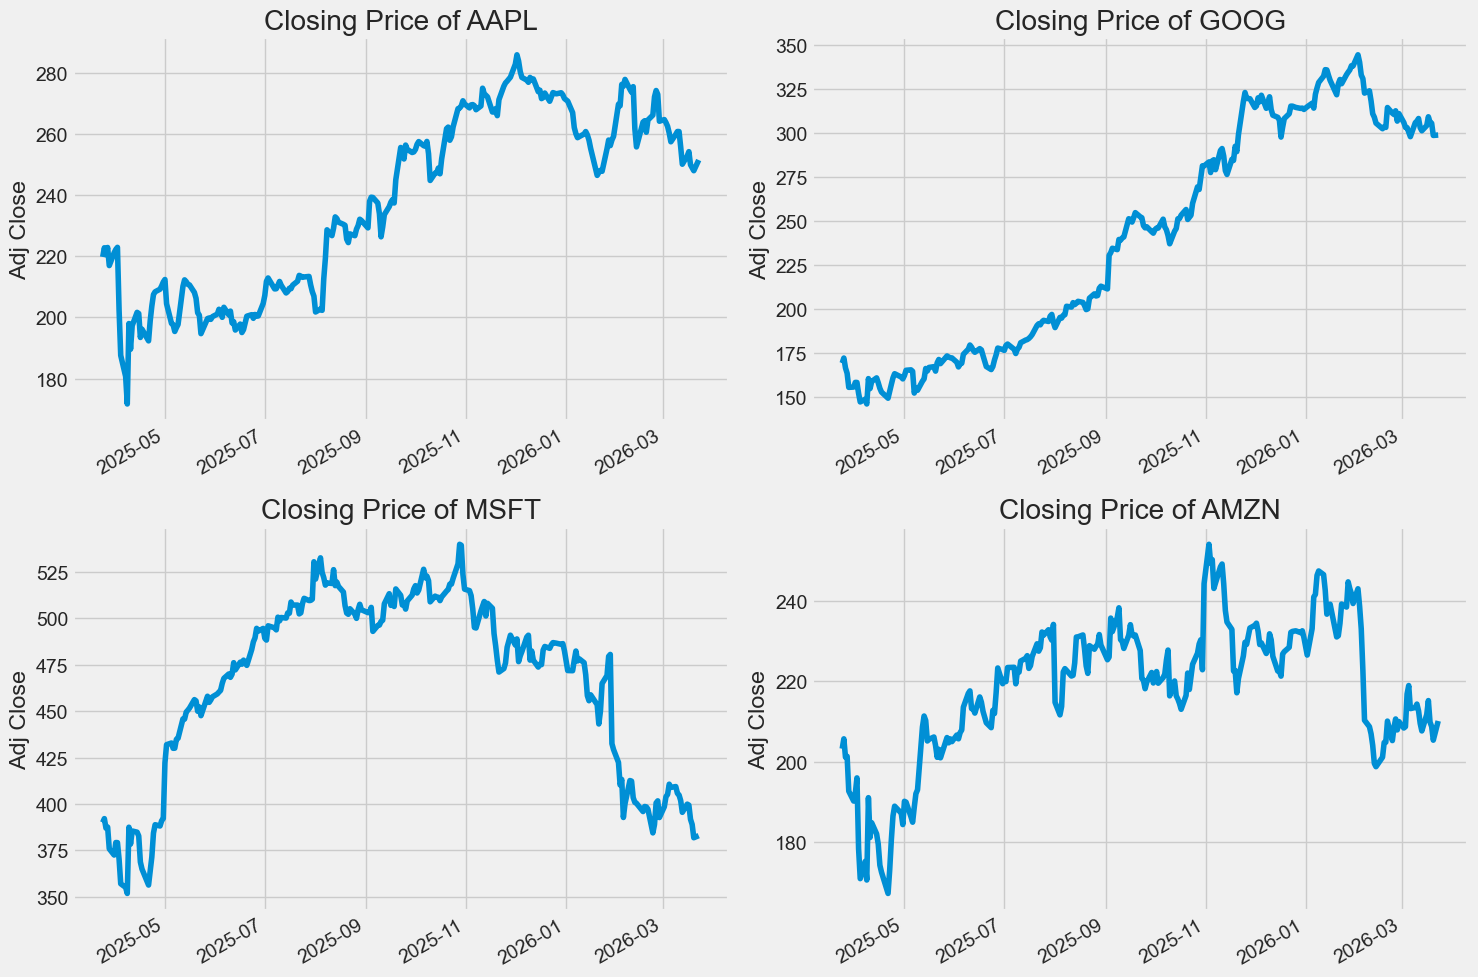

In [4]:
# Let's see a historical view of the closing price
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=0.05)

for i, ticker in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    # Zugriff auf Adj Close für den jeweiligen Ticker
    stocks['Adj Close'][ticker].plot()
    
    plt.ylabel('Adj Close')
    plt.xlabel(None)
    plt.title(f"Closing Price of {ticker}")

plt.tight_layout()
plt.show()

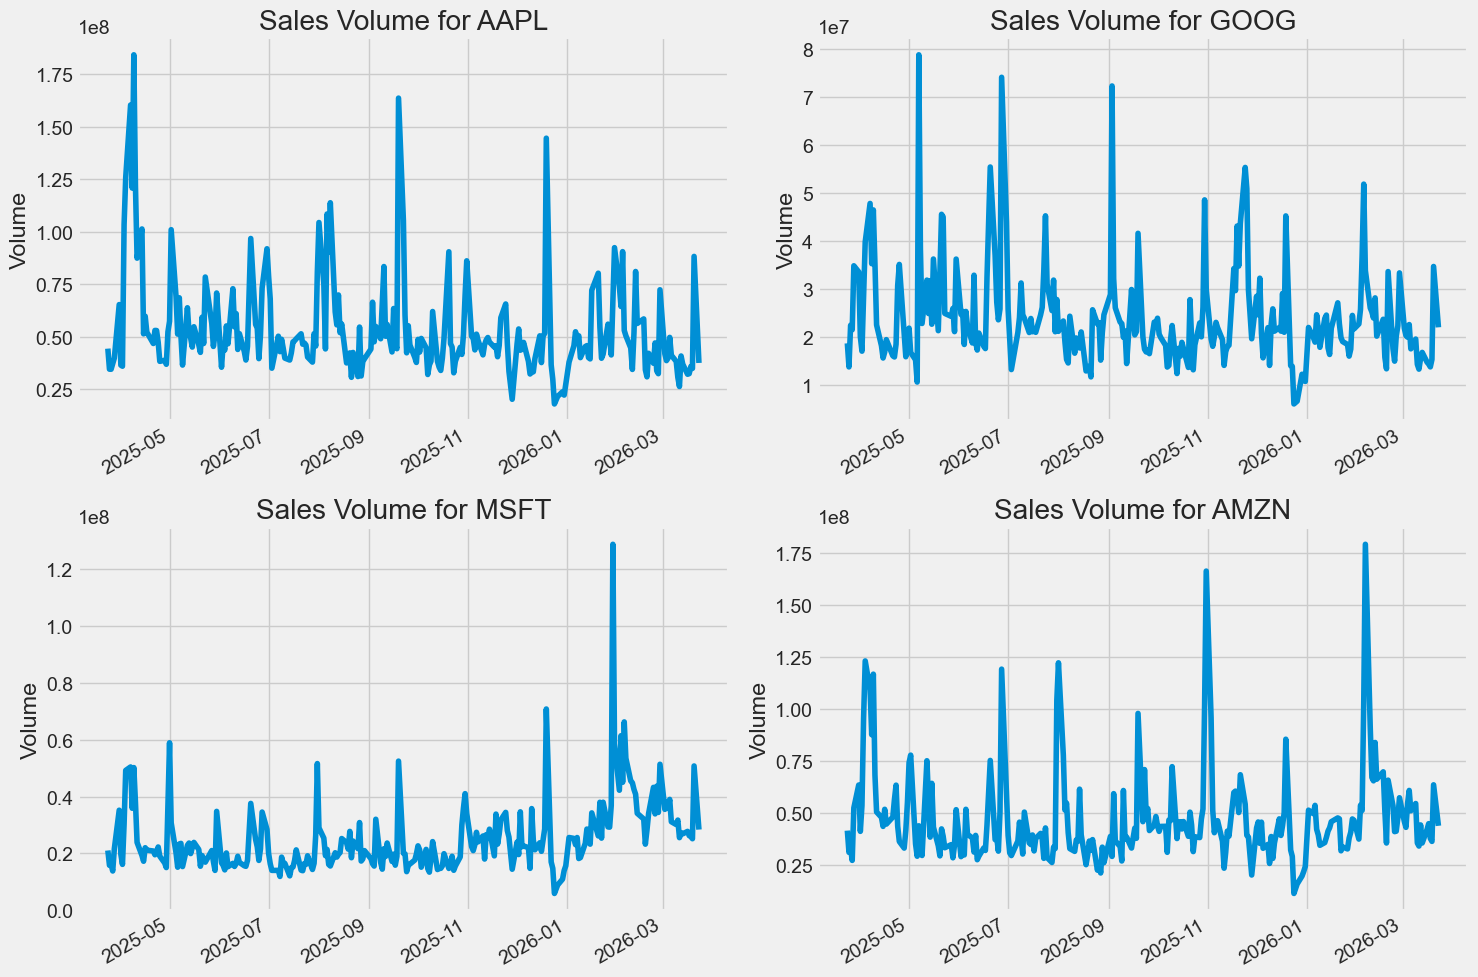

In [5]:
# Now let's plot the total volume of stock being traded each day
plt.figure(figsize=(15, 10))
plt.subplots_adjust(top=1.25, bottom=1.2)

for i, ticker in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    stocks['Volume'][ticker].plot()
    plt.ylabel('Volume')
    plt.xlabel(None)
    plt.title(f"Sales Volume for {company_list[i - 1]}")
    
plt.tight_layout()
plt.show()

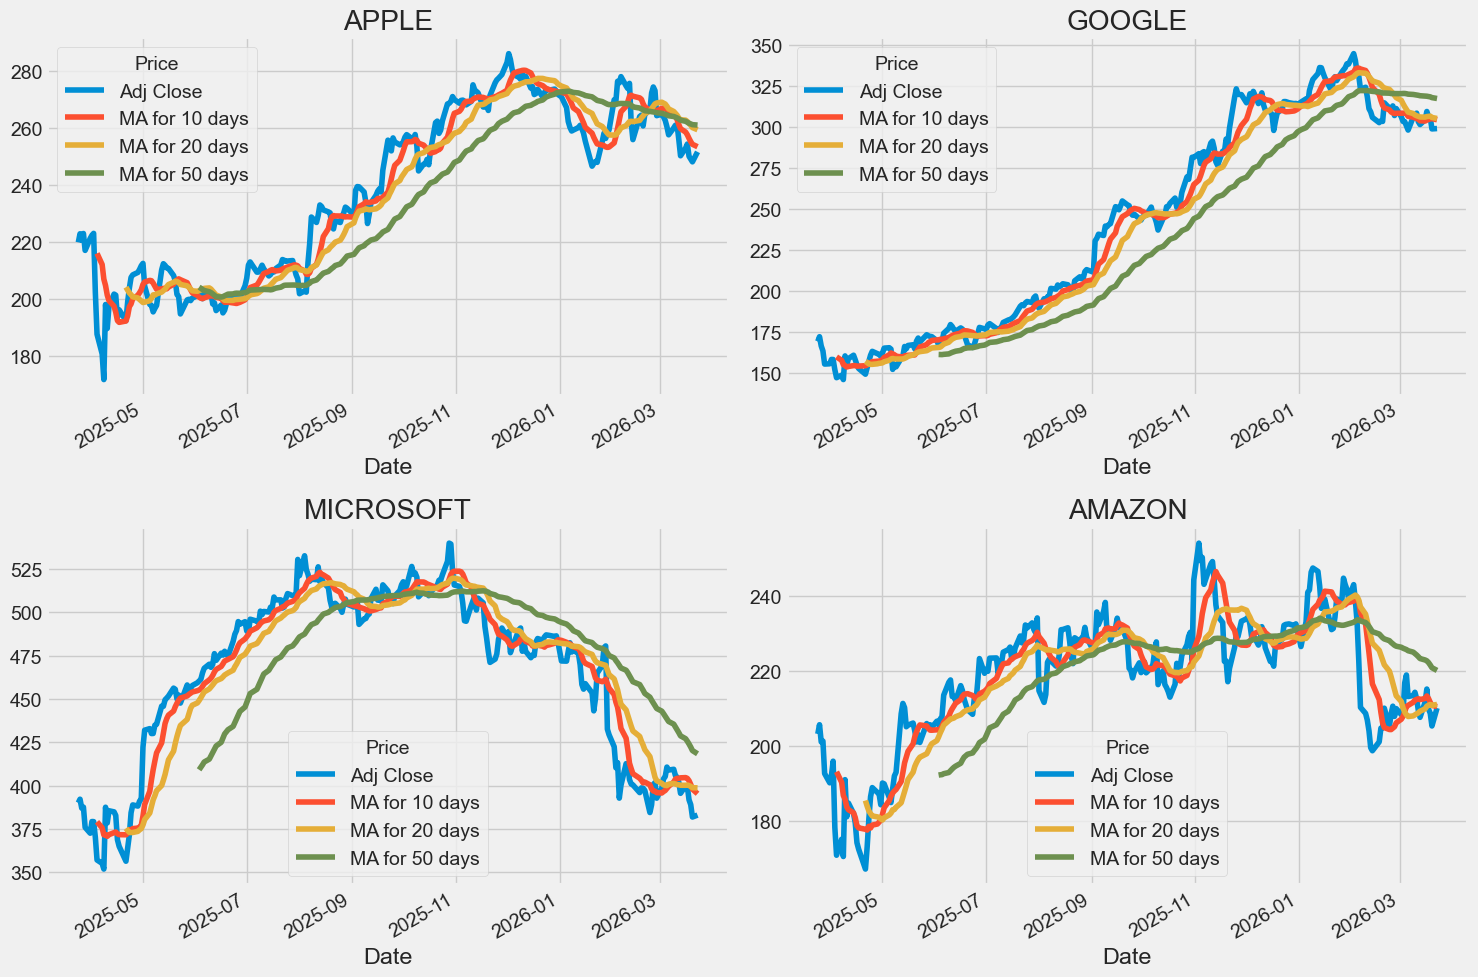

In [6]:
#Moving Average
ma_day = [10, 20, 50]

for ticker in company_list:
    for ma in ma_day:
        column_name = f"MA for {ma} days"
        stocks[(column_name, ticker)] = stocks['Adj Close'][ticker].rolling(ma).mean()

#Jetzt enthält ma_prices['AAPL'] die Spalten:
#Close, MA for 10 days, MA for 20 days, MA for 50 days

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15,10))

stocks.xs('AAPL', axis=1, level=1)[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,0])
axes[0,0].set_title('APPLE')

stocks.xs('GOOG', axis=1, level=1)[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[0,1])
axes[0,1].set_title('GOOGLE')

stocks.xs('MSFT', axis=1, level=1)[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,0])
axes[1,0].set_title('MICROSOFT')

stocks.xs('AMZN', axis=1, level=1)[['Adj Close', 'MA for 10 days', 'MA for 20 days', 'MA for 50 days']].plot(ax=axes[1,1])
axes[1,1].set_title('AMAZON')


fig.tight_layout()
plt.show()

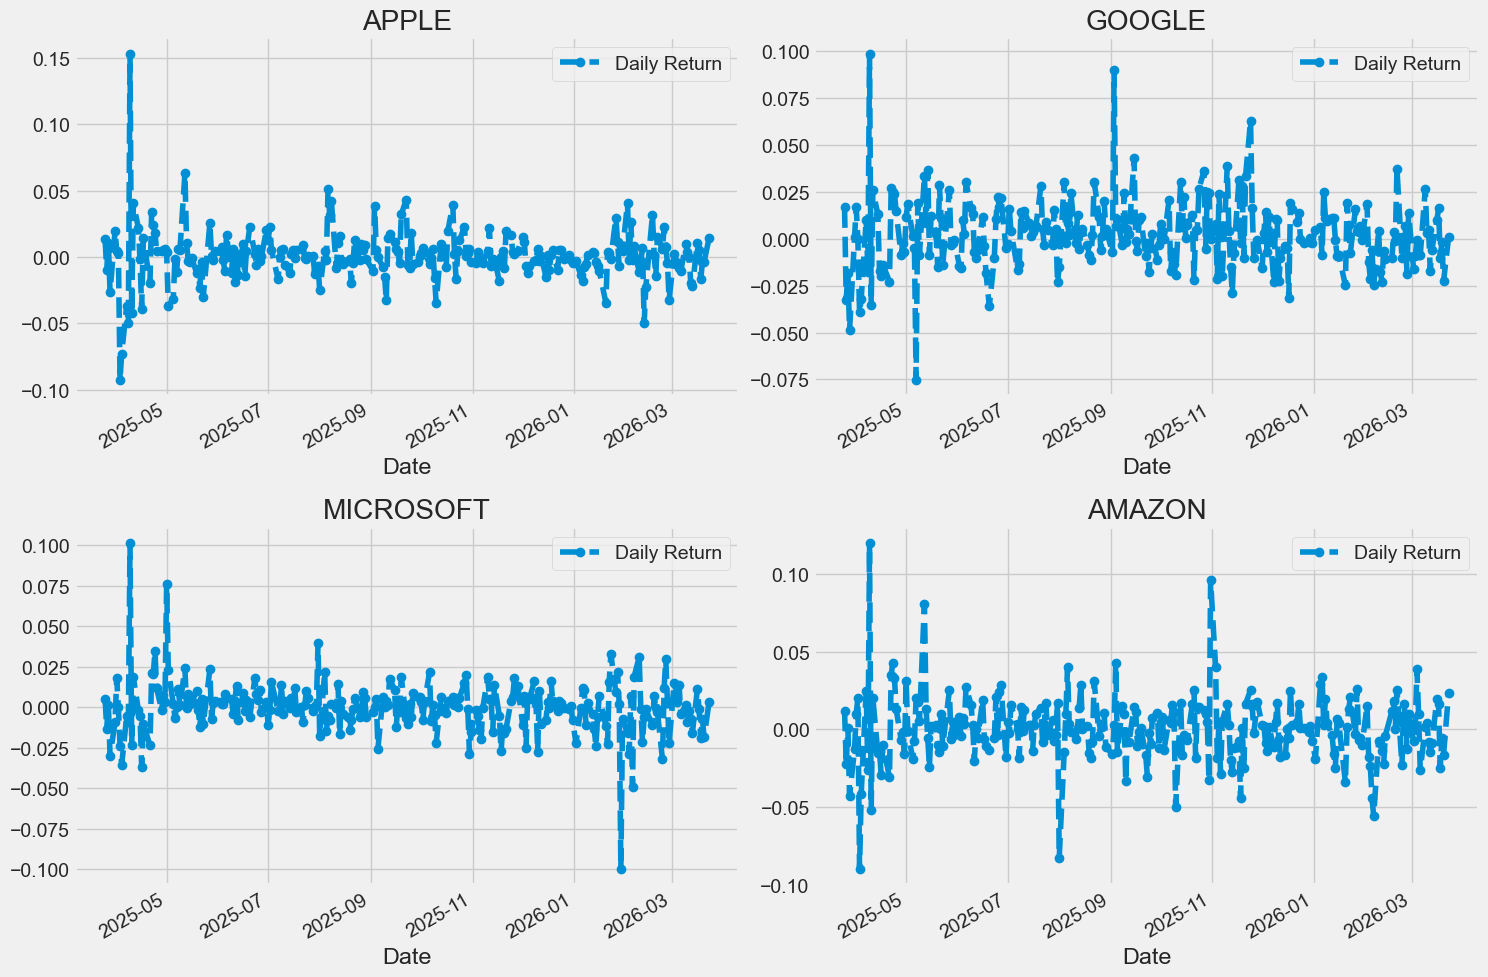

Ticker,AAPL,GOOG,MSFT,AMZN
Date,,,,
2025-03-24,NaN,NaN,NaN,NaN
2025-03-25,0.013682,0.016831,0.005292,0.012054
2025-03-26,-0.009922,-0.032699,-0.013134,-0.022264
2025-03-27,0.010473,-0.018308,0.001564,0.001144
2025-03-28,-0.026580,-0.048879,-0.030160,-0.042908
...,...,...,...,...
2026-03-17,0.005577,0.016392,-0.001350,0.016341
2026-03-18,-0.016874,-0.010051,-0.019078,-0.024768
2026-03-19,-0.003921,-0.001861,-0.007070,-0.005289


In [7]:
#Daily return of the stock (risk analysis)
# We'll use pct_change to find the percent change for each day

for ticker in company_list:
    stocks[('Daily Return', ticker)] = stocks['Adj Close'][ticker].pct_change()

fig, axes = plt.subplots(nrows=2, ncols=2)
fig.set_figheight(10)
fig.set_figwidth(15)


stocks.xs('AAPL', axis=1, level=1)['Daily Return'].plot(ax=axes[0,0], legend=True, linestyle='--', marker='o')
axes[0,0].set_title('APPLE')

stocks.xs('GOOG', axis=1, level=1)['Daily Return'].plot(ax=axes[0,1], legend=True, linestyle='--', marker='o')
axes[0,1].set_title('GOOGLE')

stocks.xs('MSFT', axis=1, level=1)['Daily Return'].plot(ax=axes[1,0], legend=True, linestyle='--', marker='o')
axes[1,0].set_title('MICROSOFT')

stocks.xs('AMZN', axis=1, level=1)['Daily Return'].plot(ax=axes[1,1], legend=True, linestyle='--', marker='o')
axes[1,1].set_title('AMAZON')

fig.tight_layout()
plt.show()
stocks['Daily Return']

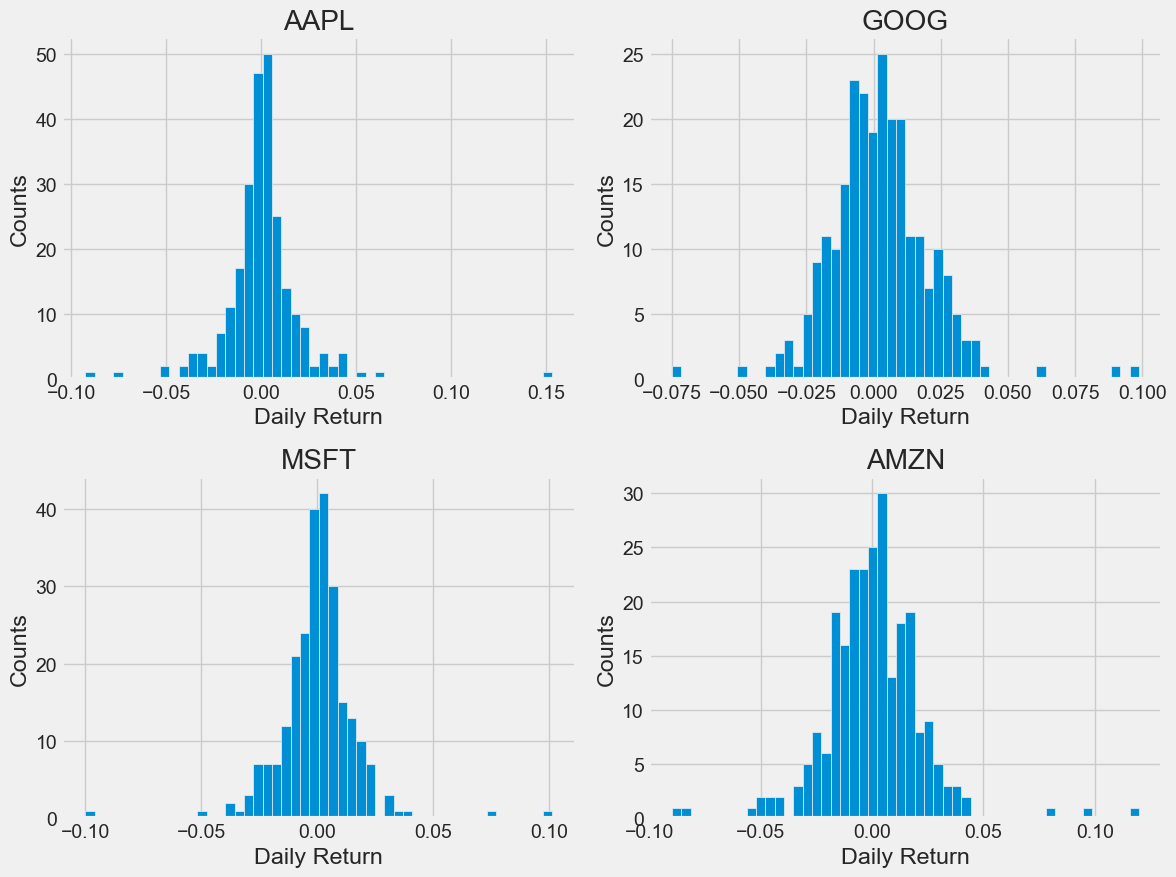

In [8]:
#average daily return using a histogram
plt.figure(figsize=(12, 9))

for i, ticker in enumerate(company_list, 1):
    plt.subplot(2, 2, i)
    stocks['Daily Return'][ticker].hist(bins=50)
    plt.xlabel('Daily Return')
    plt.ylabel('Counts')
    plt.title(f'{ticker}')
    
plt.tight_layout()
plt.show()

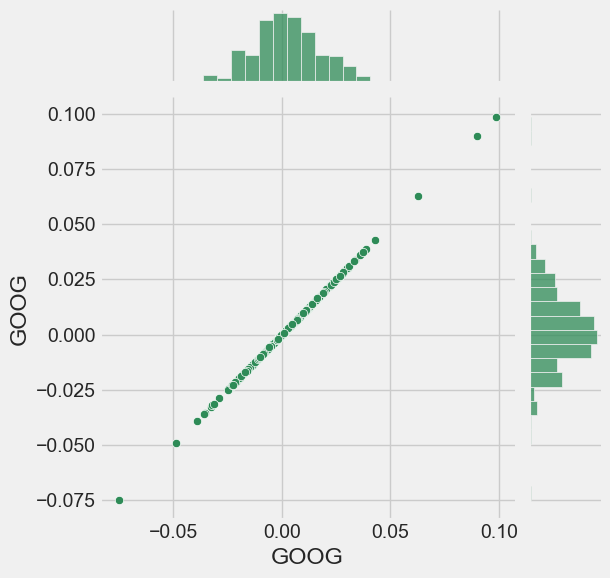

In [9]:
# Comparing Google to itself should show a perfectly linear relationship
sns.jointplot(x='GOOG', y='GOOG', data=stocks['Daily Return'], kind='scatter', color='seagreen')

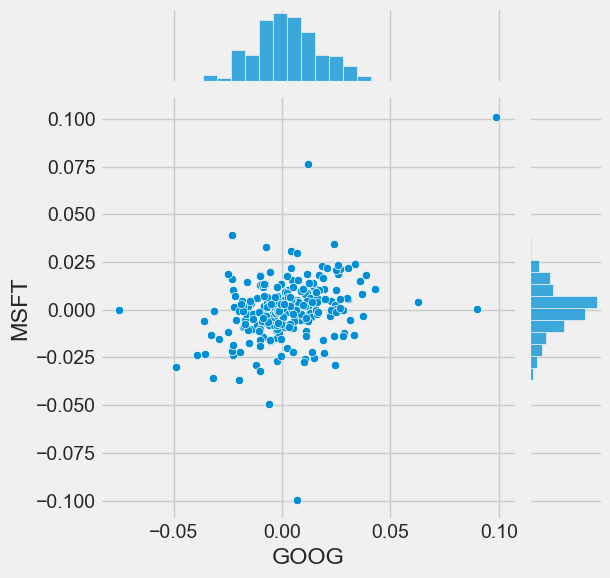

In [10]:
# We'll use joinplot to compare the daily returns of Google and Microsoft
sns.jointplot(x='GOOG', y='MSFT', data=stocks['Daily Return'], kind='scatter')

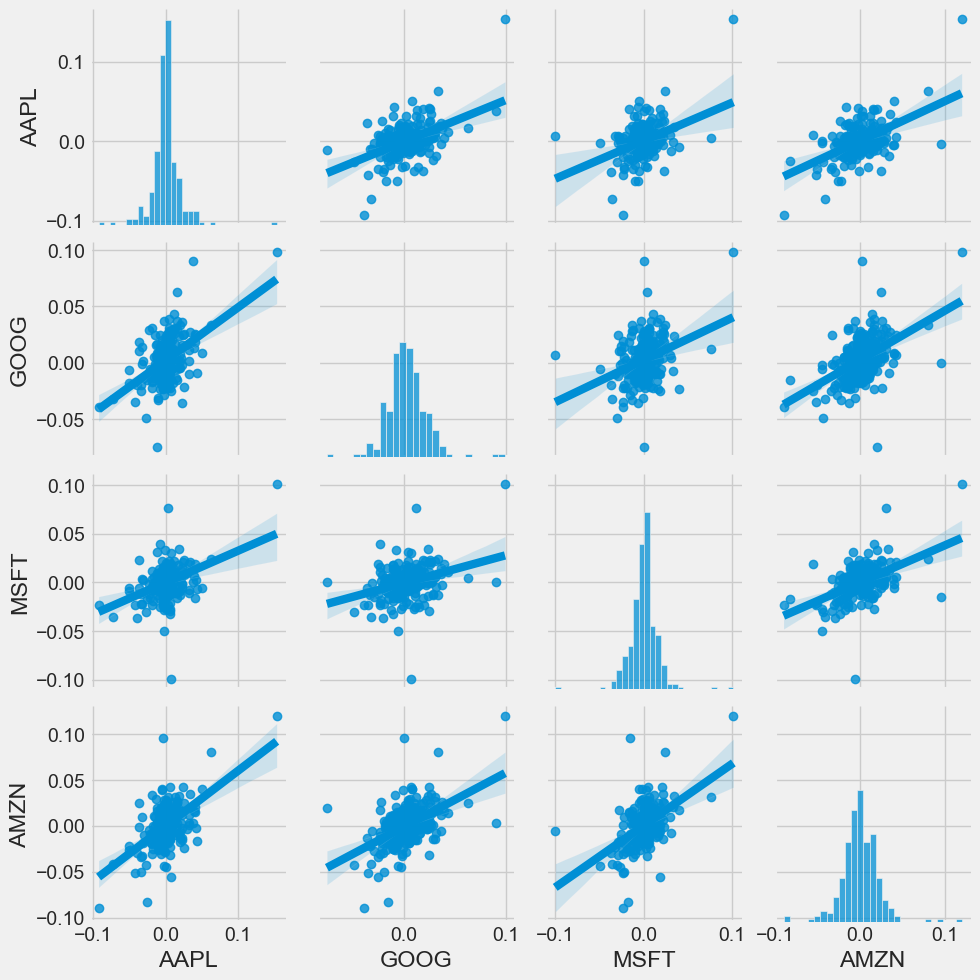

In [11]:
# We can simply call pairplot on our DataFrame for an automatic visual analysis 
# of all the comparisons

sns.pairplot(stocks['Daily Return'], kind='reg')

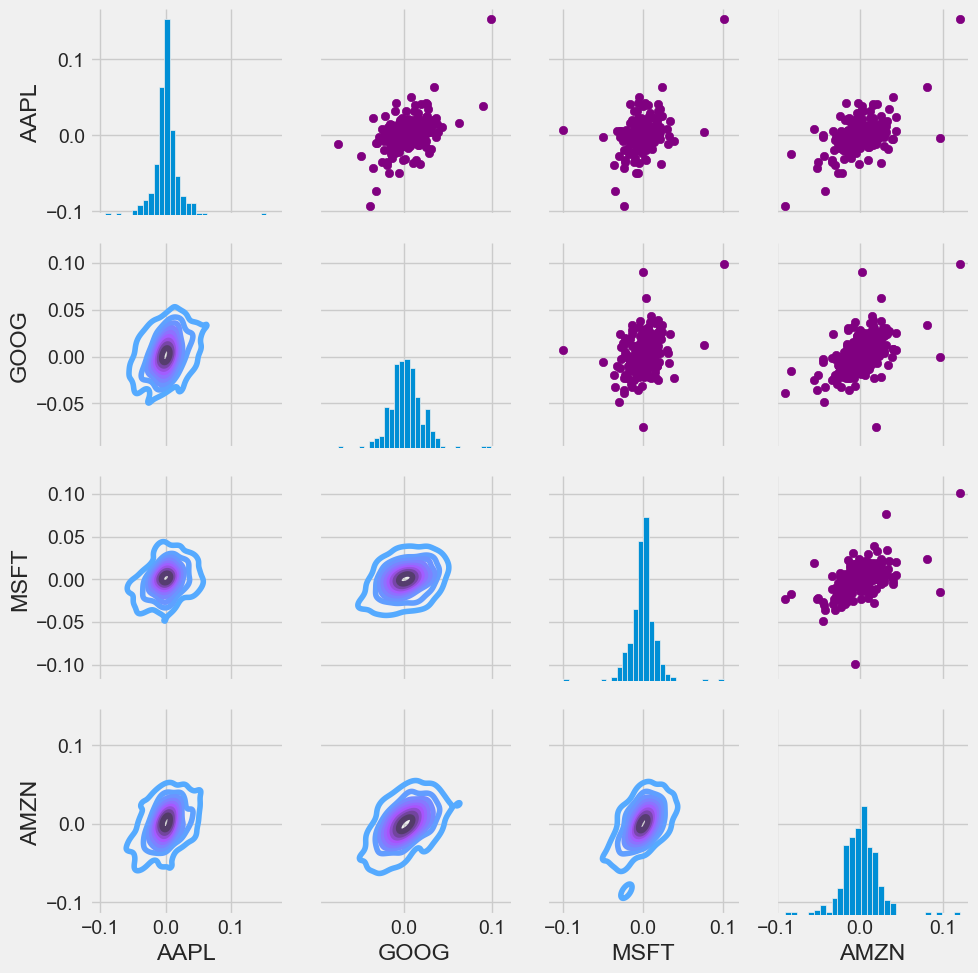

In [12]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
return_fig = sns.PairGrid(stocks['Daily Return'].dropna())

# Using map_upper we can specify what the upper triangle will look like.
return_fig.map_upper(plt.scatter, color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) 
# or the color map (BluePurple)
return_fig.map_lower(sns.kdeplot, cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
return_fig.map_diag(plt.hist, bins=30)

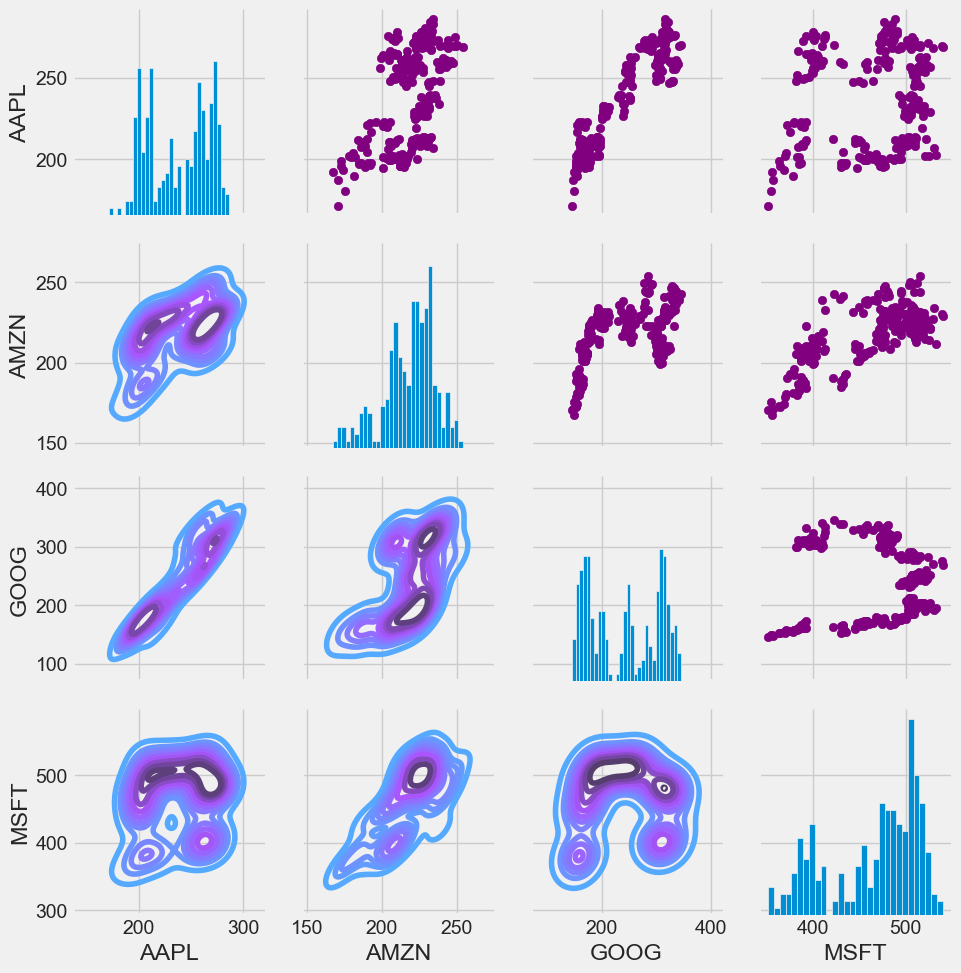

In [13]:
# Set up our figure by naming it returns_fig, call PairPLot on the DataFrame
returns_fig = sns.PairGrid(stocks['Adj Close'])

# Using map_upper we can specify what the upper triangle will look like.
returns_fig.map_upper(plt.scatter,color='purple')

# We can also define the lower triangle in the figure, inclufing the plot type (kde) or the color map (BluePurple)
returns_fig.map_lower(sns.kdeplot,cmap='cool_d')

# Finally we'll define the diagonal as a series of histogram plots of the daily return
returns_fig.map_diag(plt.hist,bins=30)

Text(0.5, 1.0, 'Correlation of stock closing price')

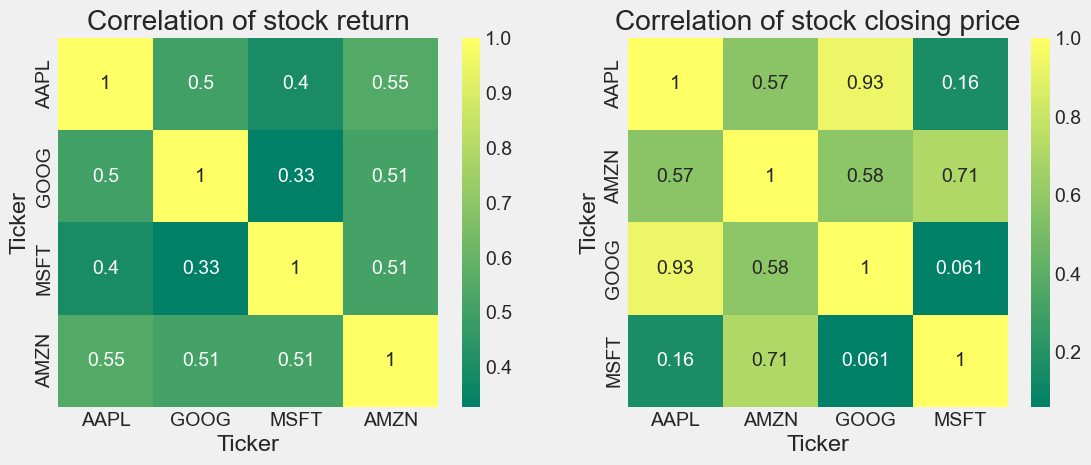

In [14]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.heatmap(stocks['Daily Return'].corr(), annot=True, cmap='summer')
plt.title('Correlation of stock return')

plt.subplot(2, 2, 2)
sns.heatmap(stocks['Adj Close'].corr(), annot=True, cmap='summer')
plt.title('Correlation of stock closing price')

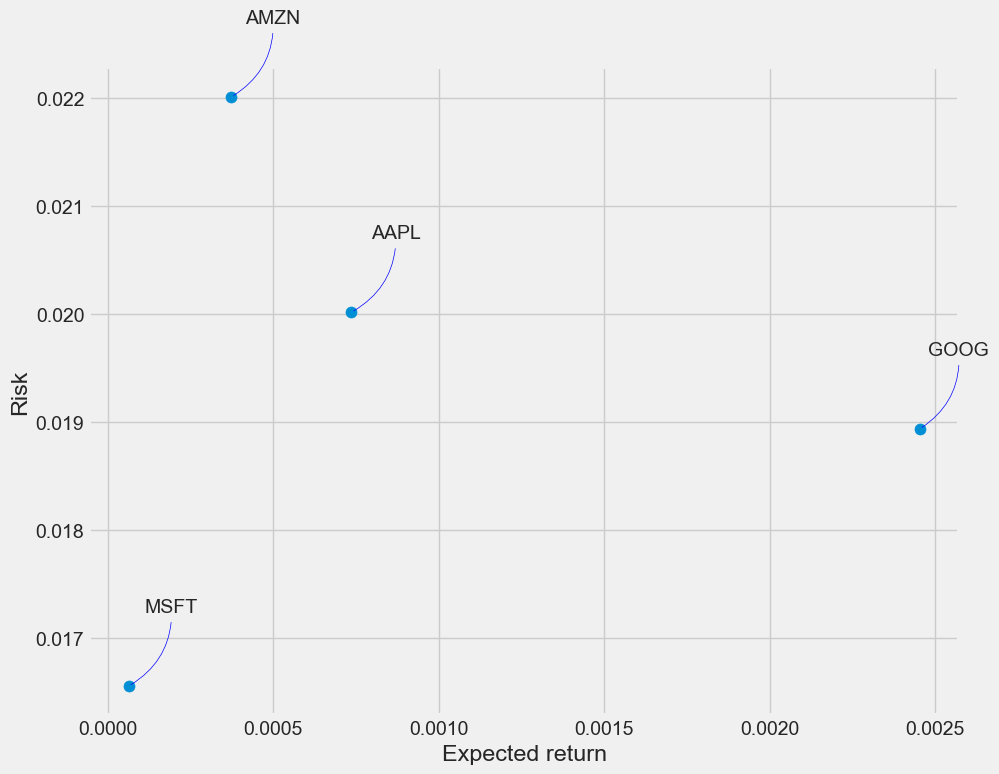

In [15]:
rets = stocks['Daily Return'].dropna()

area = np.pi * 20

plt.figure(figsize=(10, 8))
plt.scatter(rets.mean(), rets.std(), s=area)
plt.xlabel('Expected return')
plt.ylabel('Risk')

for label, x, y in zip(rets.columns, rets.mean(), rets.std()):
    plt.annotate(label, xy=(x, y), xytext=(50, 50), textcoords='offset points', ha='right', va='bottom', 
                 arrowprops=dict(arrowstyle='-', color='blue', connectionstyle='arc3,rad=-0.3'))

In [16]:
# Get the stock quote
df = yf.download("AAPL", start="2012-01-01", end=datetime.now(), auto_adjust=False)
df.columns = df.columns.droplevel(1)
# Show the data
df.head()
df.columns

[*********************100%***********************]  1 of 1 completed


Index(['Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')

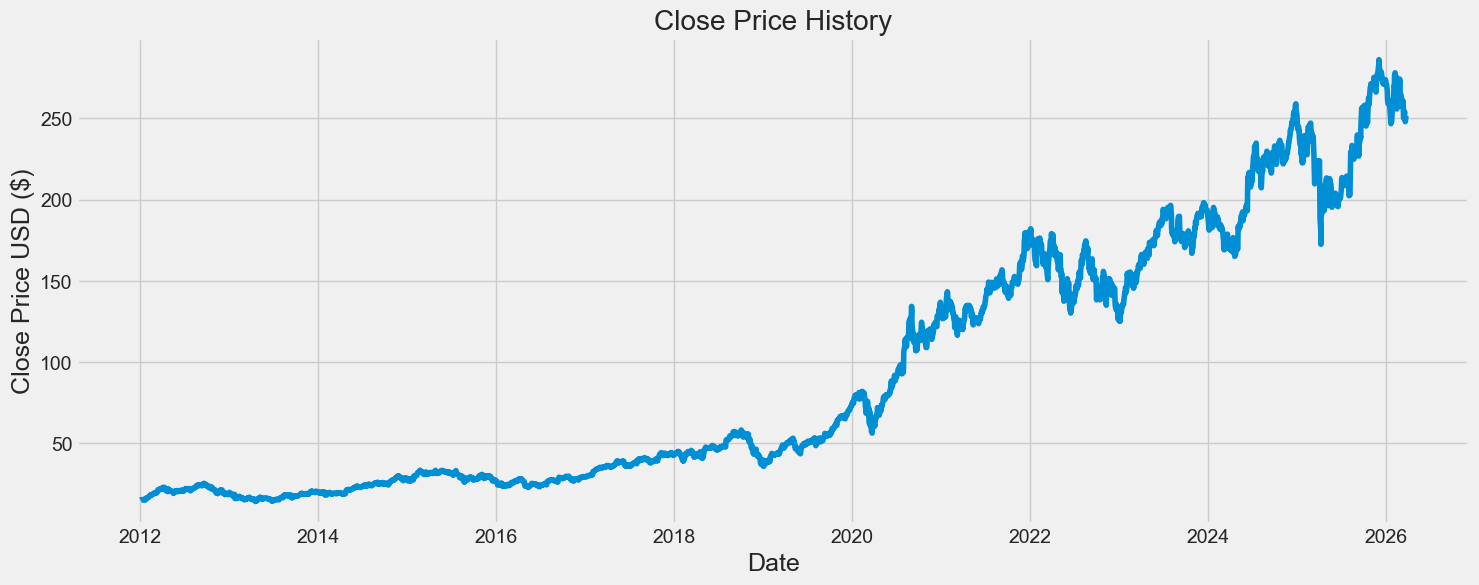

In [17]:
plt.figure(figsize=(16,6))
plt.title('Close Price History')
plt.plot(df['Close'])
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.show()

In [18]:
# Create a new dataframe with only the 'Close column 
data = df.filter(['Close'])
# Convert the dataframe to a numpy array
dataset = data.values
# Get the number of rows to train the model on
training_data_len = int(np.ceil( len(dataset) * .95 ))
training_data_len

3397

In [19]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.00271554],
       [0.00300546],
       [0.0036076 ],
       ...,
       [0.86324694],
       [0.85968393],
       [0.87254012]], shape=(3575, 1))

In [20]:
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
X_train = []
y_train = []

for i in range(60, len(train_data)):
    X_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(X_train)
        print(y_train)
        print()
        
# Convert the X_train and y_train to numpy arrays 
X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape the data
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_train.shape

[array([0.00271554, 0.00300546, 0.0036076 , 0.00418088, 0.00409299,
       0.00429108, 0.00420056, 0.00404838, 0.00384111, 0.00448261,
       0.00506114, 0.00488273, 0.00390539, 0.00483812, 0.00391982,
       0.00736344, 0.00709714, 0.00744478, 0.00819647, 0.00865168,
       0.00861364, 0.00847327, 0.00907148, 0.00963426, 0.01027183,
       0.01130164, 0.01346489, 0.01349768, 0.01470197, 0.0156019 ,
       0.01405522, 0.0146508 , 0.014639  , 0.01630899, 0.01607154,
       0.01651101, 0.01730075, 0.01774023, 0.01900616, 0.01992839,
       0.0201947 , 0.02028785, 0.018711  , 0.01833056, 0.01838697,
       0.01986937, 0.02028654, 0.02118254, 0.02329462, 0.02611249,
       0.02558512, 0.02558643, 0.02762374, 0.02826131, 0.0278074 ,
       0.02739286, 0.02696126, 0.02839511, 0.02937901, 0.02979093])]
[np.float64(0.02877292760128025)]

[array([0.00271554, 0.00300546, 0.0036076 , 0.00418088, 0.00409299,
       0.00429108, 0.00420056, 0.00404838, 0.00384111, 0.00448261,
       0.00506114, 0.00

(3337, 60, 1)

In [21]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (X_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(X_train, y_train, batch_size=32, epochs=20)

/Users/platongkotzamanidis/Desktop/Stockmarket/.venv/lib/python3.13/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


3337/3337 ━━━━━━━━━━━━━━━━━━━━ 62s 18ms/step - loss: 7.9562e-04


In [22]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002 
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
X_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    X_test.append(test_data[i-60:i, 0])
    
# Convert the data to a numpy array
X_test = np.array(X_test)

# Reshape the data
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1 ))

# Get the models predicted price values 
predictions = model.predict(X_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


np.float64(33.037736548596435)

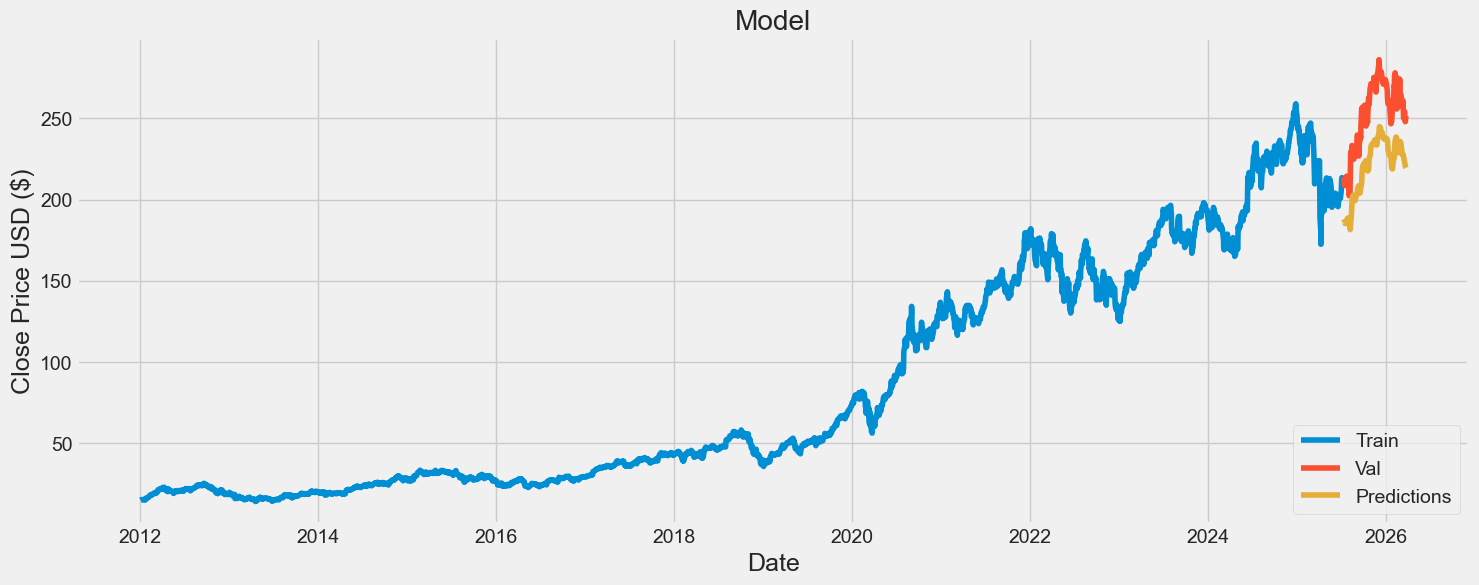

In [23]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [24]:
valid

,Close,Predictions
Date,,
2025-07-09,211.139999,185.629364
2025-07-10,212.410004,185.813187
2025-07-11,211.160004,186.163620
2025-07-14,208.619995,186.263321
2025-07-15,209.110001,185.789688
...,...,...
2026-03-17,254.229996,223.232910
2026-03-18,249.940002,222.634140
2026-03-19,248.960007,221.629761


In [192]:
#Monte Carlo simmulation 
#Die Simulation basiert meist auf Geometric Brownian Motion:
#S_{t+1} = S_t*exp((\mu-\sigma^2/2)*\Delta_t + \sigma \sqrt(\Delta_t)*Z)
#S_t = aktueller Preis
#\mu = durchschnittliche Rendite 
#\sigma = Volatilität
#Z = Zufallsvariable N(0,1)
#\Delta_t = Zeitschritt

In [193]:
#Calculate daily returns
returns = df['Adj Close'].pct_change().dropna()
mu = returns.mean()
sigma = returns.std()
T = 252 #trading days (1 year)
simmulations = 1000
S_0 = df['Adj Close'].iloc[-1]
dt = 1

In [194]:
#Array for simmulations
price_paths = np.zeros((T, simmulations)) #shape = (252,100)
price_paths[0] = S_0  #first row = [S_0, S_0, ..., S_0]

#Run simmulations
for t in range(1,T):
    Z = np.random.standard_normal(simmulations)
    price_paths[t] = price_paths[t-1]*np.exp(
        (mu - 0.5 * sigma**2 * dt) + sigma * np.sqrt(dt) * Z
    )

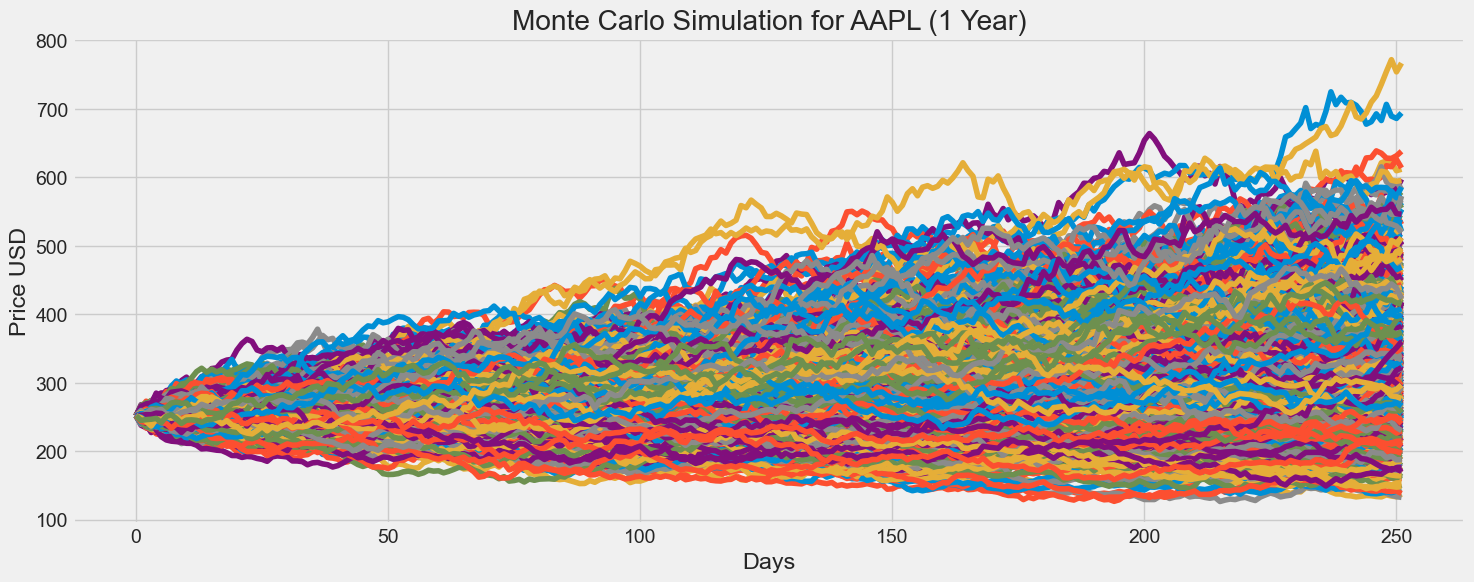

In [195]:
#Plot simmulations
plt.figure(figsize=(16,6))
plt.plot(price_paths)
plt.title("Monte Carlo Simulation for AAPL (1 Year)")
plt.xlabel("Days")
plt.ylabel("Price USD")
plt.show()

In [196]:
# Expected price after 1 year
expected_price = price_paths[-1].mean()
print("Expected price after 1 year:", expected_price)

Expected price after 1 year: 321.80246924200594


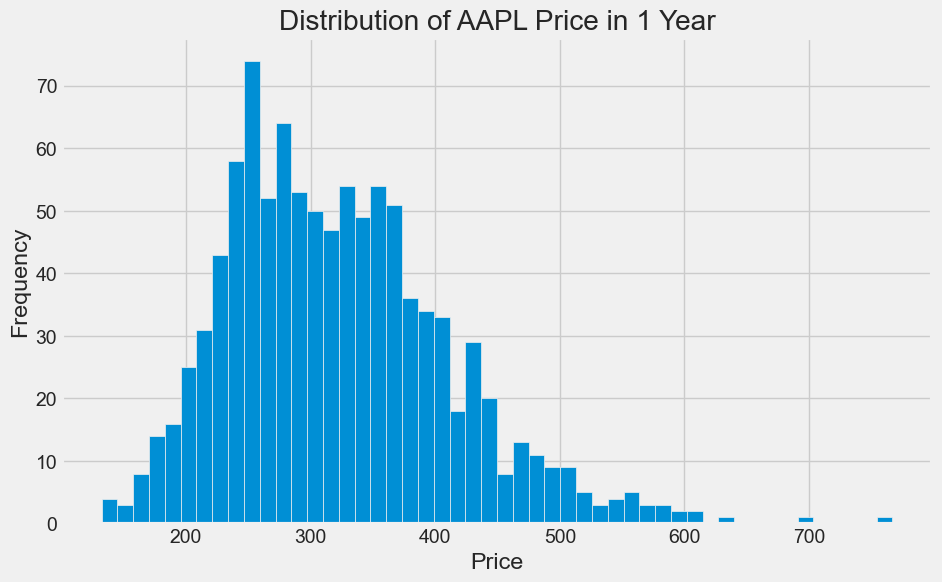

In [197]:
#Distribution of the forecasted prices
plt.figure(figsize=(10,6))
plt.hist(price_paths[-1], bins=50)
plt.title("Distribution of AAPL Price in 1 Year")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

In [198]:
#Probability that the price increases 
probability_up = np.mean(price_paths[-1] > S_0)
print("Probability price increases:", probability_up)

Probability price increases: 0.762


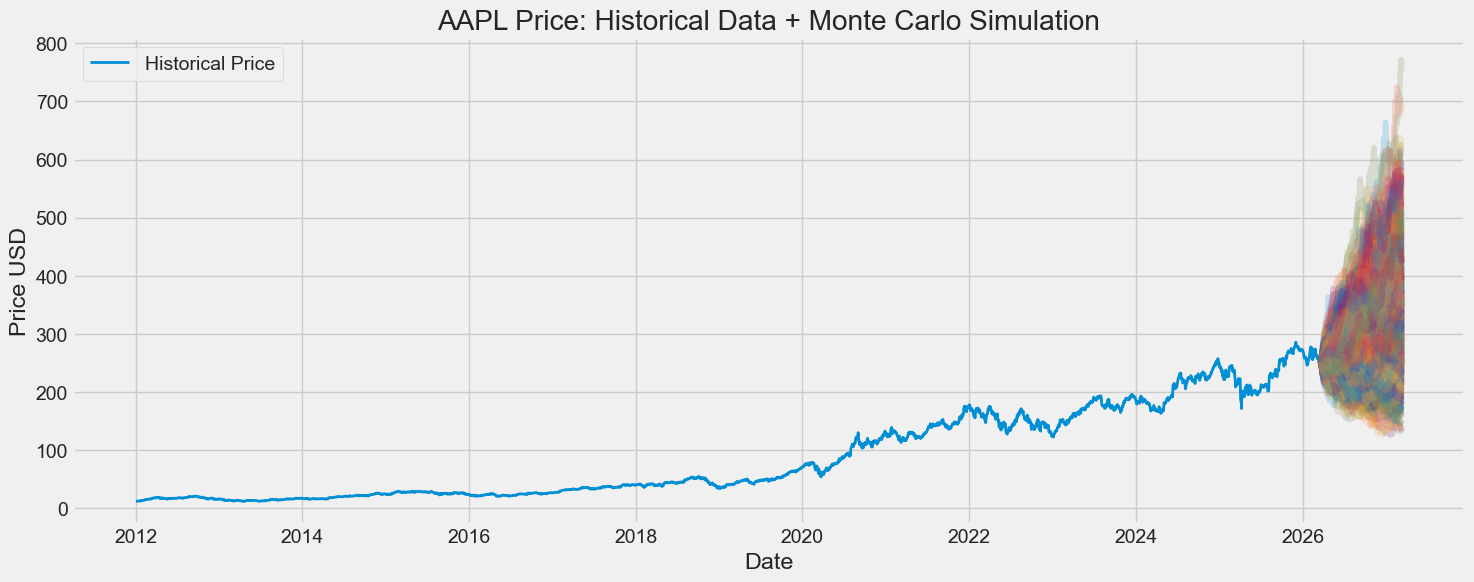

In [199]:
# Zeitachse für Simulation erstellen
last_date = df.index[-1]
future_dates = pd.date_range(start=last_date, periods=T+1, freq='B')[1:]

# Plot
plt.figure(figsize=(16,6))

# Historische Preise
plt.plot(df.index, df['Adj Close'], label="Historical Price", linewidth=2)

# Monte Carlo Simulationen
for i in range(simmulations):
    plt.plot(future_dates, price_paths[:, i], alpha=0.2)

plt.title("AAPL Price: Historical Data + Monte Carlo Simulation")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.show()

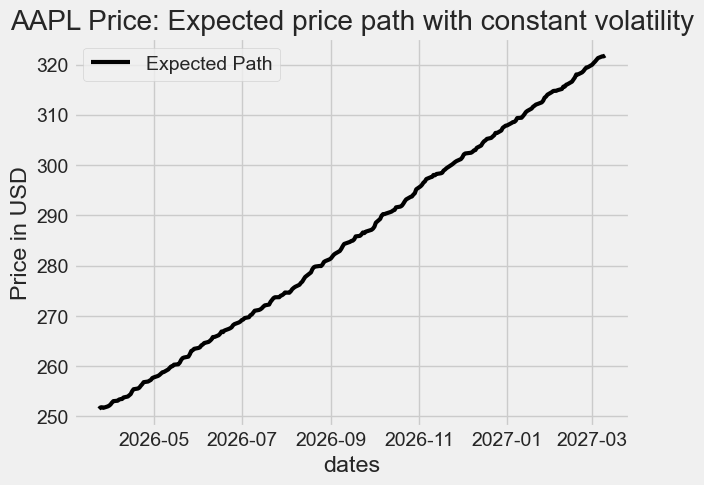

In [205]:
expected_path = price_paths.mean(axis=1)
plt.plot(future_dates, expected_path, color='black', linewidth=3, label='Expected Path')
plt.title("AAPL Price: Expected price path with constant volatility")
plt.xlabel("dates")
plt.ylabel("Price in USD")
plt.legend()

In [206]:
# Erwartungswert und Konfidenzintervalle
median_path = np.median(price_paths, axis=1)
p5 = np.percentile(price_paths, 5, axis=1)
p95 = np.percentile(price_paths, 95, axis=1)

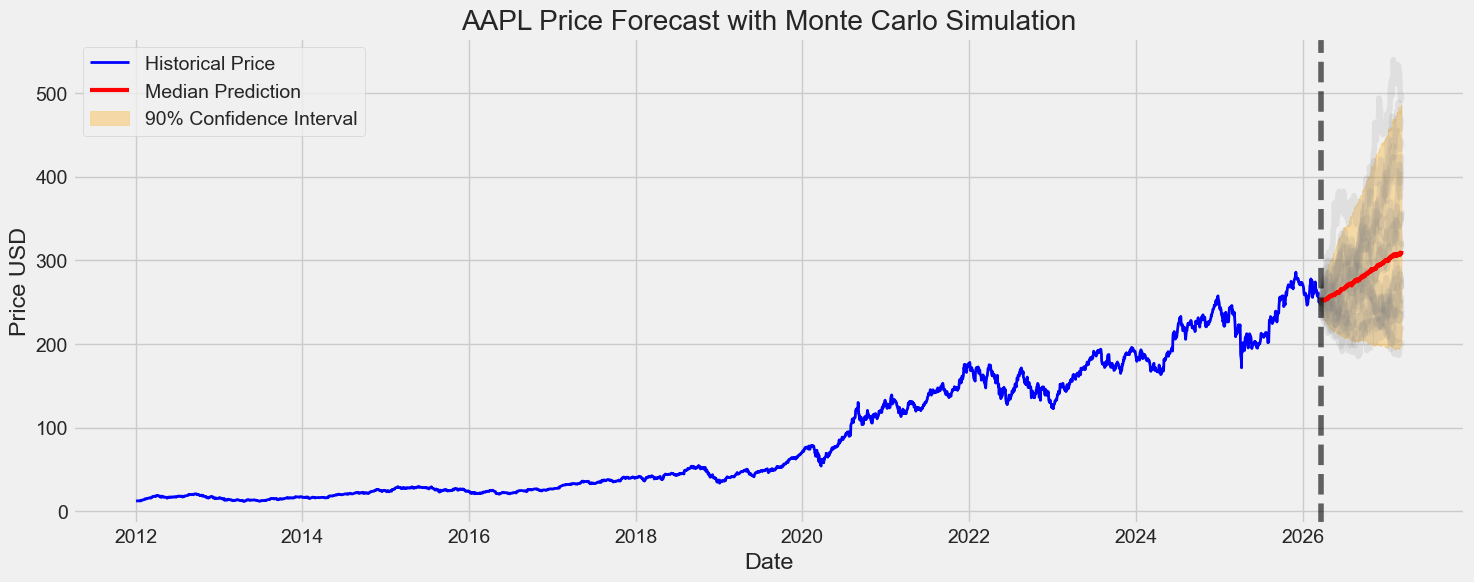

In [207]:
plt.figure(figsize=(16,6))

# Historische Preise
plt.plot(df.index, df['Adj Close'], label="Historical Price", color="blue", linewidth=2)

# Einige Simulationen (nicht alle!)
for i in range(20):
    plt.plot(future_dates, price_paths[:, i], color="gray", alpha=0.15)

# Median Pfad
plt.plot(future_dates, median_path, color="red", linewidth=3, label="Median Prediction")

# Konfidenzbereich
plt.fill_between(future_dates, p5, p95, color="orange", alpha=0.3, label="90% Confidence Interval")

# Linie zwischen Vergangenheit und Zukunft
plt.axvline(df.index[-1], linestyle="--", color="black", alpha=0.6)

plt.title("AAPL Price Forecast with Monte Carlo Simulation")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.show()

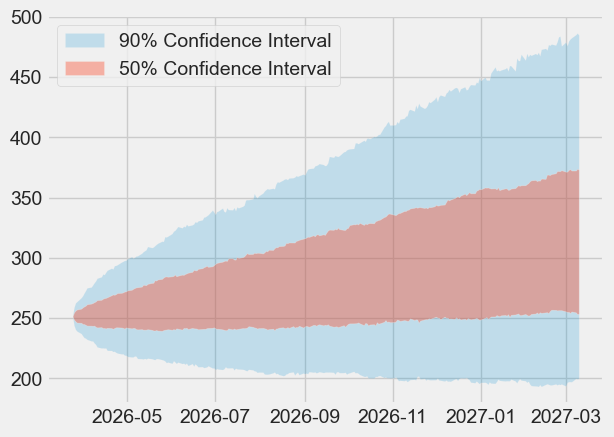

In [208]:
p5 = np.percentile(price_paths, 5, axis=1)
p25 = np.percentile(price_paths, 25, axis=1)
p75 = np.percentile(price_paths, 75, axis=1)
p95 = np.percentile(price_paths, 95, axis=1)

plt.fill_between(future_dates, p5, p95, alpha=0.2, label = "90% Confidence Interval")
plt.fill_between(future_dates, p25, p75, alpha=0.4, label="50% Confidence Interval")
plt.legend()

In [212]:
prob_above_300 = np.mean(price_paths[-1] > 300)
prob_below_200 = np.mean(price_paths[-1] < 200)
print("P(APPL price > 300$) = ", prob_above_300)
print("P(APPL price < 200$) = ", prob_below_200)

P(APPL price > 300$) =  0.542
P(APPL price < 200$) =  0.052


In [213]:
#Value at Risk VaR
#VaR = Percentile(returns)
var_95 = np.percentile(price_paths[-1], 5)
var_95

np.float64(199.85392223103113)

In [214]:
#Non-constant volatility \sigma
vol_series = returns.rolling(30).std().dropna().values
sigma_t = vol_series[-T:]

#Array for simmulations
price_paths_variable = np.zeros((T, simmulations)) #shape = (252,100)
price_paths_variable[0] = S_0  #first row = [S_0, S_0, ..., S_0]

#Run simmulations
for t in range(1,T):
    volatility = sigma_t[t]
    Z = np.random.standard_normal(simmulations)
    price_paths_variable[t] = price_paths_variable[t-1]*np.exp(
        (mu - 0.5 * volatility**2 * dt) + volatility * np.sqrt(dt) * Z
    )

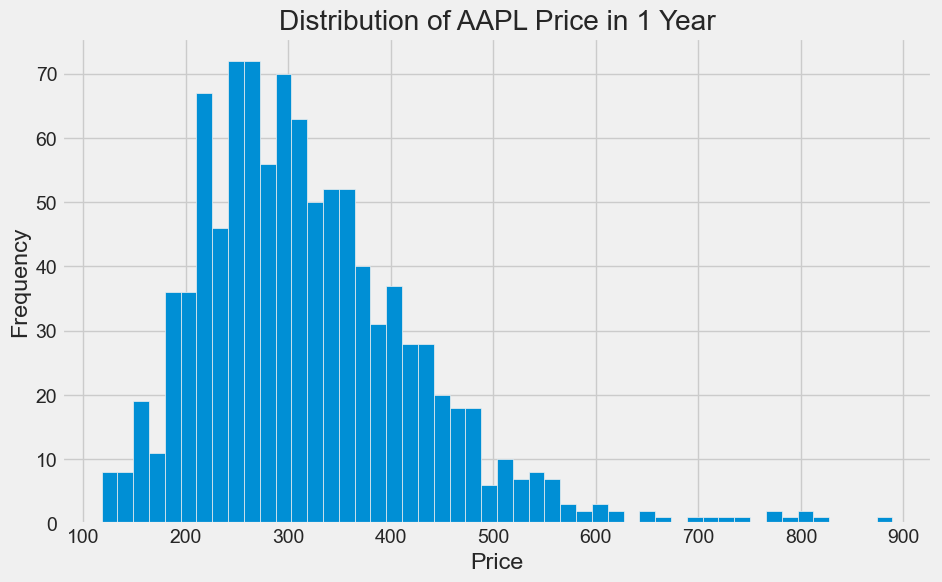

In [216]:
#Distribution of the forecasted prices
plt.figure(figsize=(10,6))
plt.hist(price_paths_variable[-1], bins=50)
plt.title("Distribution of AAPL Price in 1 Year")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

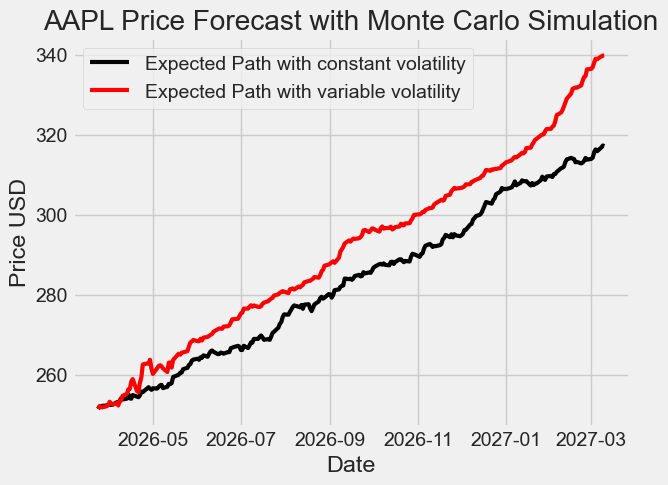

In [189]:
#Comparisson of the expected path: constant vs non-constant volatility
expected_path_const = price_paths.mean(axis=1)
expected_path_variable = price_paths_variable.mean(axis=1)
plt.plot(future_dates, expected_path_const, color='black', linewidth=3, label='Expected Path with constant volatility')
plt.plot(future_dates, expected_path_variable, color='red', linewidth=3, label='Expected Path with variable volatility')
plt.title("AAPL Price Forecast with Monte Carlo Simulation")
plt.xlabel("Date")
plt.ylabel("Price USD")
plt.legend()
plt.show()